In [1]:
#@python 3.8.10
#@author moon ying
#plot continuum membrane results with matplotlib 3d plot and trimesh package
#dependencies are listed as follows

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import trimesh as tr
import re
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
import seaborn as sns
sns.set_context("talk")

import pyvista as pv
import vtk
from pyvistaqt import BackgroundPlotter

# use one of...
from pykdtree.kdtree import KDTree
# from scipy.spatial import cKDTree as KDTree

In [2]:
# input and output file name string
infile = "vertexfinal.csv"
outfile = "change_density"

# controls if figure legends are included
is_legend_plotted = False

In [3]:
vertices = pd.read_csv(infile, header = None)
vertices.columns = ["x","y","z"]
vertices

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


,x,y,z
0,-147.622609,-151.693309,-7.913525
1,-142.773380,-151.682382,-7.914072
2,-138.485316,-151.676305,-7.914124
3,-130.821672,-151.668302,-7.914114
4,-127.036041,-151.671403,-7.913767
...,...,...,...
4326,131.514684,151.676305,-7.914128
4327,135.955318,151.669545,-7.914116
4328,142.963959,151.671403,-7.913813
4329,147.678715,151.687831,-7.913040


# Plot exaggerated

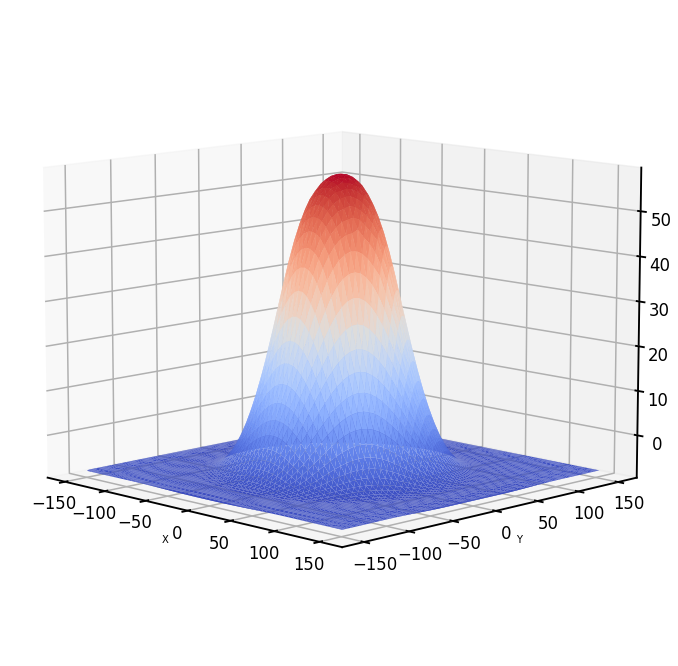

In [4]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')

#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], cmap=cm.coolwarm)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev = 10, azim = -45)
plt.savefig(outfile + "gagsonly_10deg_with_axis.svg", format = 'svg')

# Read in the COM.csv and apply total shift from .log file

In [5]:
# Read in the Gag lattice file
gags = pd.read_csv("COM.csv", header = None, skiprows = 1)
gags.columns = ["x","y","z"]

# Define the log file name that contains the total membrane propagation vector
log_file = "output100.log"

# Define the pattern to search for with regular expression
pattern =re.compile(r"\[Mesh::propagate_scaffolding\(\)\] Total movement : \((-?\d+\.\d+), (-?\d+\.\d+), (-?\d+\.\d+)\)")

# Read the file and find the last matching line
last_match = None
with open(log_file, "r") as file:
    for line in file:
        match = pattern.search(line)
        if match:
            last_match = match

# If a match was found, extract the coordinates and save to a numpy array
if last_match:
    coordinates = np.array([float(last_match.group(1)),
                            float(last_match.group(2)), float(last_match.group(3))])
    print("Extracted Coordinates:", coordinates)
else:
    print("No matching line found in the log file.")

gag_lattices_shift = coordinates
gags["x"] = gags["x"] + gag_lattices_shift[0]
gags["y"] = gags["y"] + gag_lattices_shift[1]
gags["z"] = gags["z"] + gag_lattices_shift[2]
df = gags
gags

Extracted Coordinates: [-0.612736  0.192949 -0.606689]


,x,y,z
0,-19.311920,14.337011,43.555354
1,-17.121416,6.794830,46.125299
2,28.957531,8.806225,38.781263
3,-1.880860,8.124003,48.743997
4,-7.851026,15.928804,46.297362
...,...,...,...
101,24.477652,-2.154670,42.578506
102,-30.973899,4.954127,38.833531
103,8.182275,-15.415499,46.073330
104,15.776856,-14.402290,44.319476


# Plot results and COM.csv

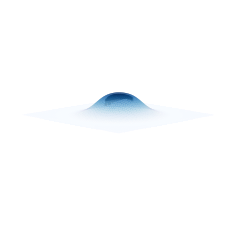

In [6]:
## fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-150.0, 150.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 10, azim = 45)

plt.savefig(outfile + "gags_membrane_10deg_uniform_scale.svg", format = 'svg')

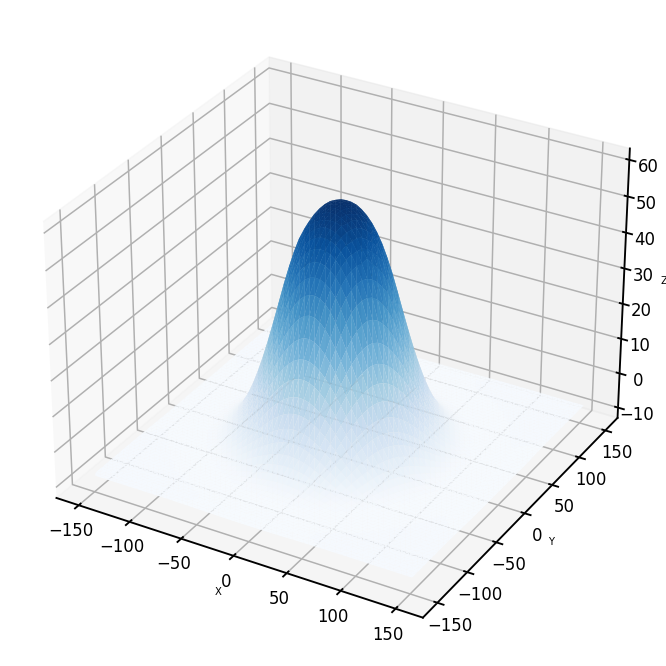

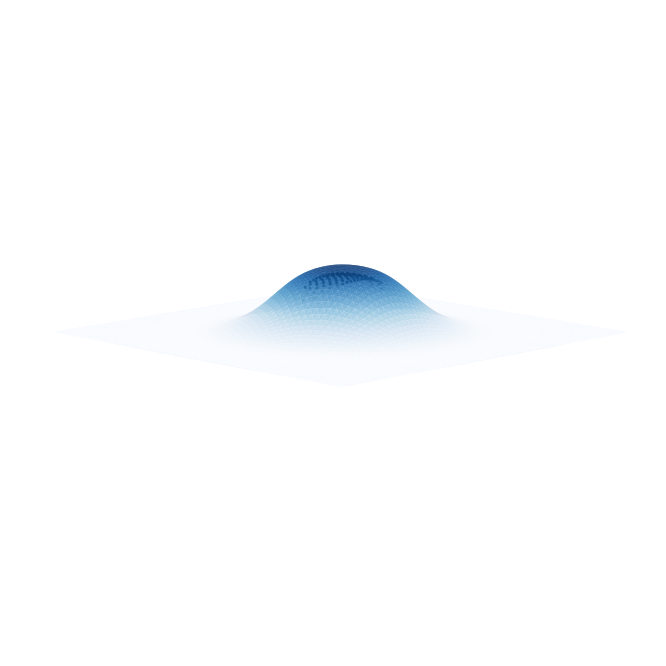

In [7]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.95, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-150.0, 150.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 10, azim = 45)


plt.savefig(outfile + "gags_membrane_10deg_uniform_scale_with_axis.svg", format = 'svg')

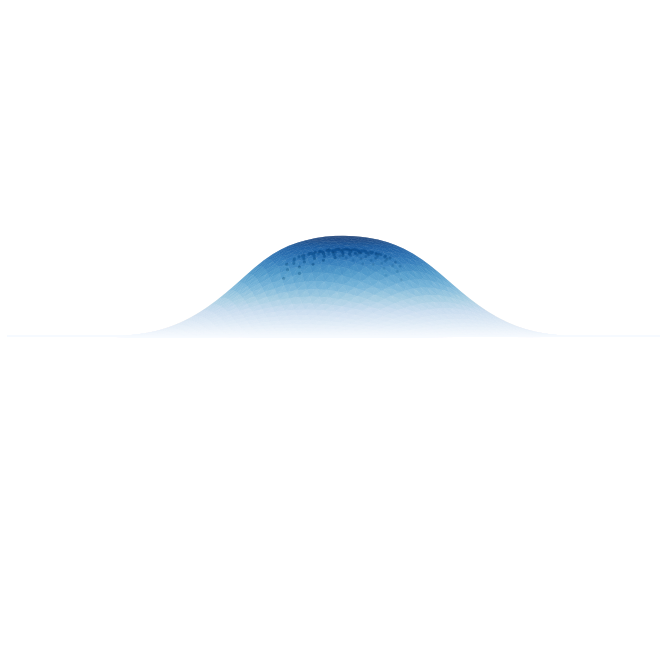

In [8]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 45)

plt.savefig(outfile + "gags_membrane_0deg_uniform_zscale.svg", format = 'svg')

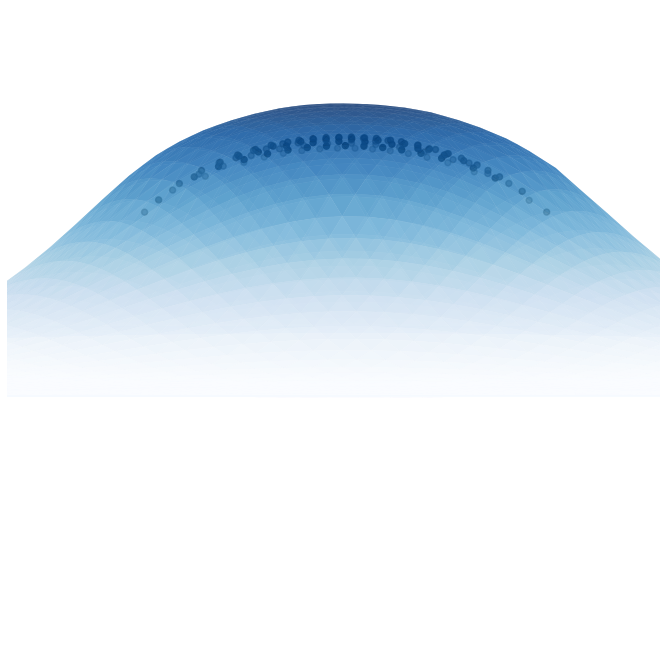

In [9]:
fig = plt.figure(figsize=(12, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.6, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 35, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-40.0, 40.0)
ax.set_ylim3d(-40.0, 40.0)
ax.set_zlim3d(-40.0, 40.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 2, azim = 90)

plt.savefig(outfile + "gags_membrane_2deg_uniform_zscale_zoomin2x.svg", format = 'svg')

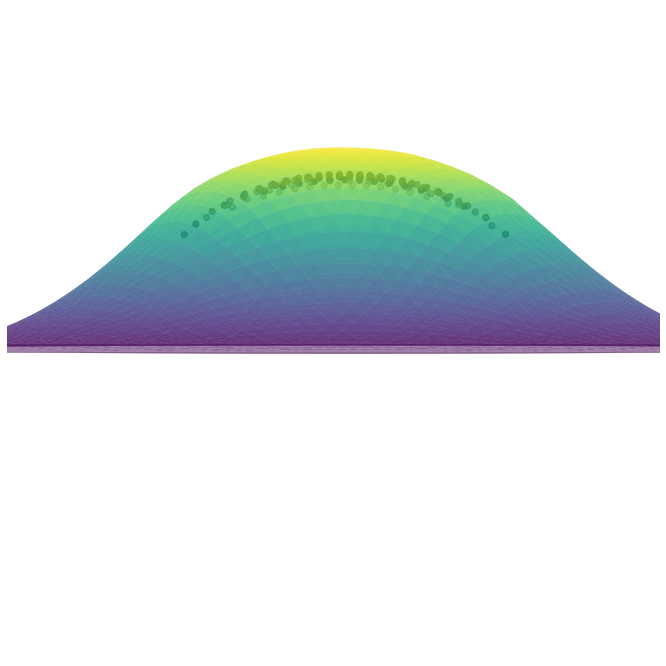

In [10]:
fig = plt.figure(figsize=(12, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="viridis", alpha = 0.6, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 35, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-50.0, 50.0)
ax.set_ylim3d(-50.0, 50.0)
ax.set_zlim3d(-50.0, 50.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 90)

plt.savefig(outfile + "gags_membrane_2deg_uniform_zscale_zoomin2x_viridis.svg", format = 'svg')

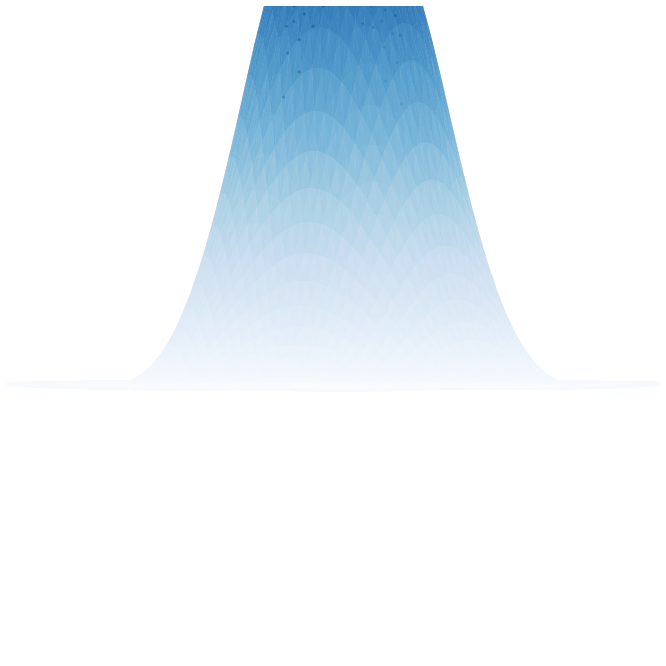

In [11]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-20.0, 20.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 45)

plt.savefig(outfile + "gags_membrane_0deg_5x_zscale.svg", format = 'svg')

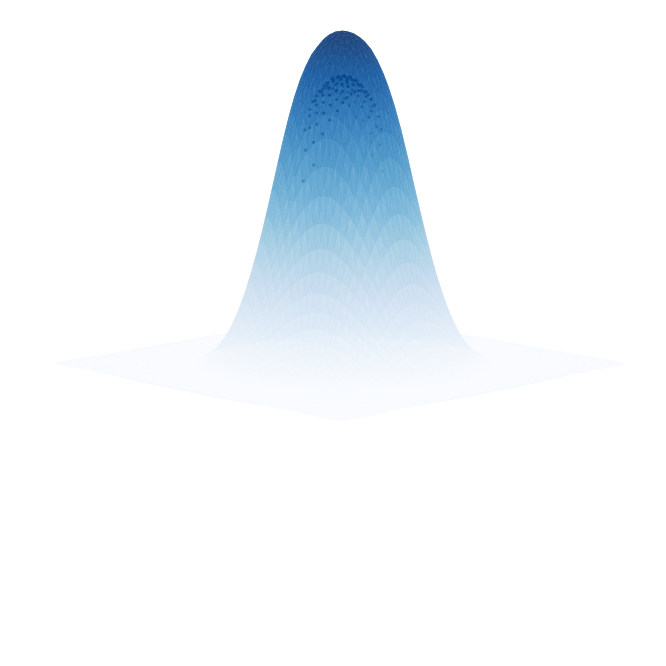

In [12]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-30.0, 30.0)
ax.set_axis_off()
if is_legend_plotted:
    ax.legend(prop={'size': 12})
ax.view_init(elev = 10, azim = 45)

plt.savefig(outfile + "gags_membrane_10deg_5x_zscale.svg", format = 'svg')

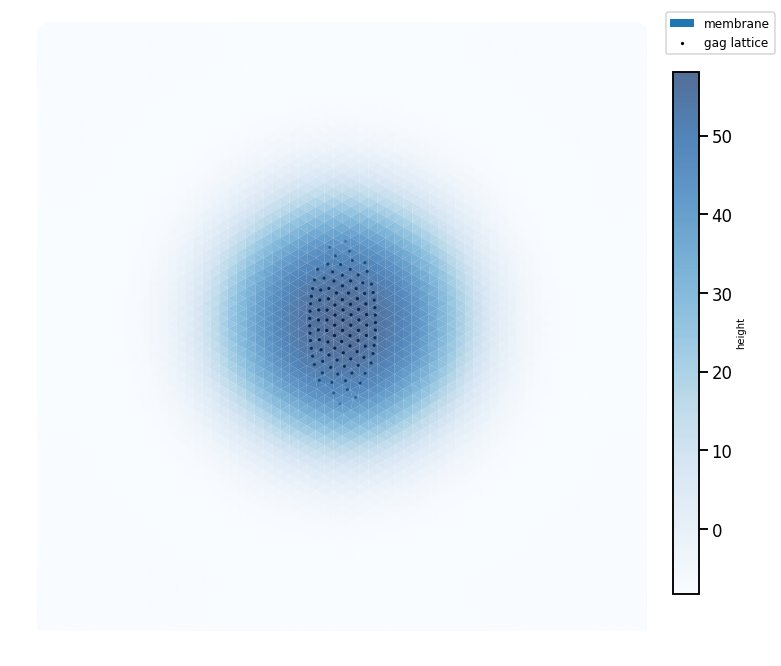

In [13]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="Blues", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, shrink = 0.8, pad = 0.01)
cbar.set_label('height')

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_membrane_topdown_uniform_zscale.svg", format = 'svg')

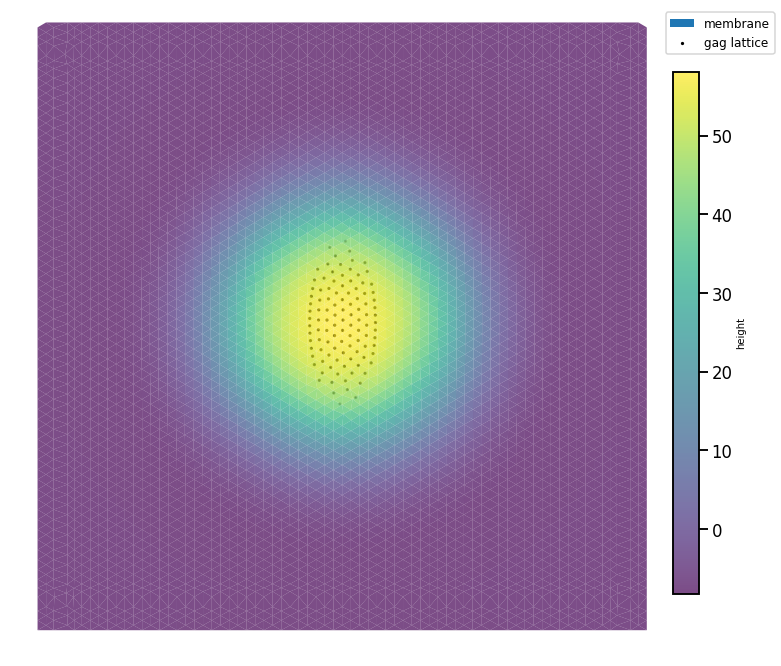

In [14]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], \
                                cmap="viridis", alpha = 0.7, label = "membrane")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_vertices._facecolors2d=surf_vertices._facecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, shrink = 0.8, pad = 0.01)
cbar.set_label('height')

scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')

ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_membrane_topdown_uniform_zscale_viridis.svg", format = 'svg')

# PyVista Subdivide


In [15]:
df_faces = pd.read_csv("face.csv", header = None)
faces = df_faces.to_numpy()
faces

array([[  61,   62,    0],
       [  62,    1,    0],
       [  62,   63,    1],
       ...,
       [4328, 4329, 4268],
       [4268, 4329, 4269],
       [4329, 4330, 4269]])

In [16]:
# VTK requires mesh faces info stores as [num_vertices, vertex1, vertex2, ...]
df_faces.insert(0, 'num', 3)
vtk_faces = df_faces.to_numpy()
vtk_faces

array([[   3,   61,   62,    0],
       [   3,   62,    1,    0],
       [   3,   62,   63,    1],
       ...,
       [   3, 4328, 4329, 4268],
       [   3, 4268, 4329, 4269],
       [   3, 4329, 4330, 4269]])

## Loop Subdivision


In [17]:
subdiv_times = 4
subfilter = "loop"

arr_x = vertices["x"].to_numpy()
arr_y = vertices["y"].to_numpy()
arr_z = vertices["z"].to_numpy()

npdat = np.transpose(np.array([arr_x, arr_y, arr_z]))

# Convert the numpy array into a pyvista mesh object
mesh = pv.PolyData(npdat, vtk_faces)

# Subdivide with pyvista module
# currently `subfilter` field supports three schemes: linear, loop, butterfly
meshsub = mesh.subdivide(subdiv_times, subfilter=subfilter)
meshsub


PolyData,Information
N Cells,2150400
N Points,1077281
N Strips,0
X Bounds,"-1.493e+02, 1.518e+02"
Y Bounds,"-1.517e+02, 1.517e+02"
Z Bounds,"-8.177e+00, 5.814e+01"
N Arrays,0


In [18]:
vertices_subdiv = meshsub.points.T
vertices_subdiv

pyvista_ndarray([[-147.2239   , -142.86653  , -137.92493  , ...,
                   150.23785  ,  150.12724  ,  149.95834  ],
                 [-150.9932   , -151.68318  , -151.676    , ...,
                   150.34198  ,  150.09557  ,  150.35681  ],
                 [  -7.9136567,   -7.9139895,   -7.914114 , ...,
                    -7.9126067,   -7.912699 ,   -7.912676 ]],
                dtype=float32)

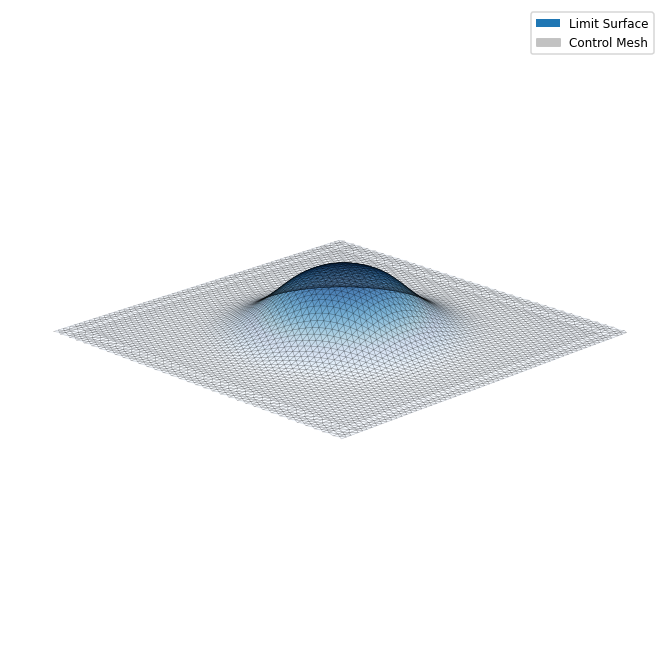

In [19]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "Blues", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], triangles = faces, \
                               cmap = "Blues", alpha = 0.24, linewidth = 0.5, edgecolor="k", label = "Control Mesh")
surf_vertices._facecolors2d=surf_vertices._edgecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors


ax.set_xlim3d(-150.0, 150.0)
ax.set_ylim3d(-150.0, 150.0)
ax.set_zlim3d(-150.0, 150.0)
ax.set_axis_off()
ax.legend(prop={'size': 12})
ax.view_init(elev = 20, azim = 45)

plt.savefig(outfile + "gags_ls_cm_20deg_uniform_scale.svg", format = "svg")

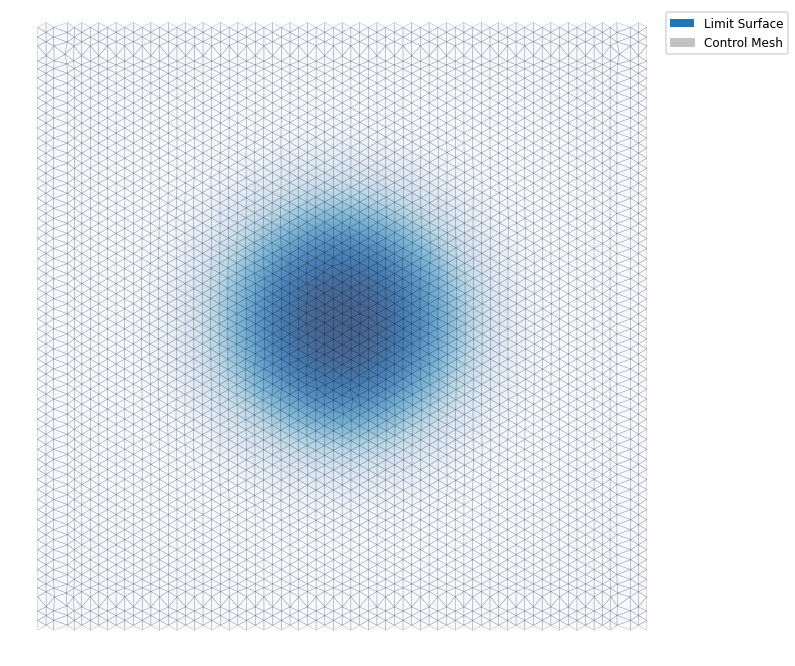

In [20]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "Blues", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, shrink = 0.8, pad = 0.01)
cbar.set_label('height')

# Plot the surface.
#surf_gags = ax.plot_trisurf(gags["x"], gags["y"], gags["z"], cmap="Oranges")
surf_vertices = ax.plot_trisurf(vertices["x"], vertices["y"], vertices["z"], triangles = faces, \
                               cmap = "Blues", alpha = 0.24, linewidth = 0.5, edgecolor="k", label = "Control Mesh")
surf_vertices._facecolors2d=surf_vertices._edgecolors
surf_vertices._edgecolors2d=surf_vertices._edgecolors


ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_ls_cm_90deg_uniform_scale.svg", format = 'svg')

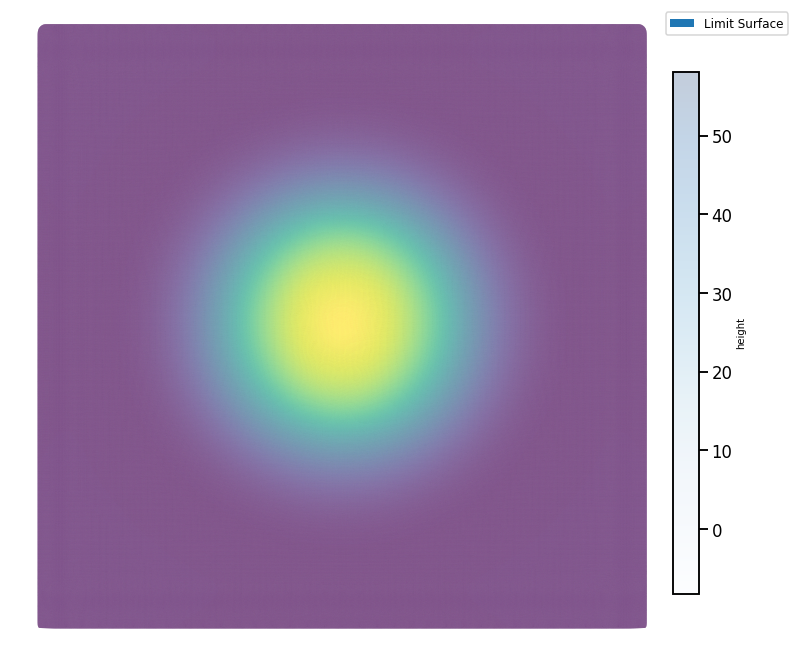

In [21]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "viridis", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Color bar
cbar = fig.colorbar(surf_vertices, ax=ax, shrink = 0.8, pad = 0.01)
cbar.set_label('height')



ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12}, loc = 'upper left', bbox_to_anchor = (1, 1))
ax.view_init(elev = 90, azim = 0)

plt.savefig(outfile + "gags_ls_cm_90deg_uniform_scale_viridis.svg", format = 'svg')

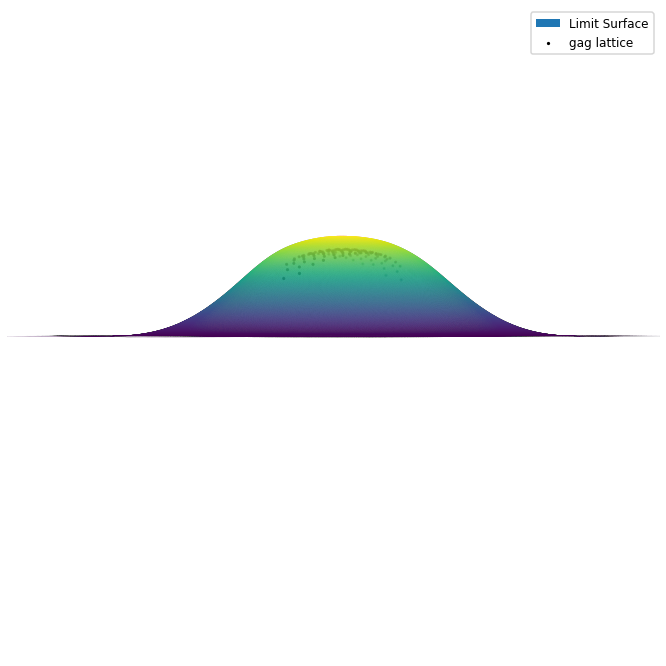

In [22]:
fig = plt.figure(figsize=(24, 12))
ax = plt.axes(projection='3d')


#ax.scatter3D(vertices["x"], vertices["y"], vertices["z"], c = vertices["z"], s = 16.0);

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})



surf_subdiv = ax.plot_trisurf(vertices_subdiv[0], \
                                vertices_subdiv[1],
                                vertices_subdiv[2], \
                               cmap = "viridis", alpha = 1.0, edgecolor="none", label = "Limit Surface")
# https://stackoverflow.com/questions/54994600/pyplot-legend-poly3dcollection-object-has-no-attribute-edgecolors2d
surf_subdiv._facecolors2d=surf_subdiv._facecolors
surf_subdiv._edgecolors2d=surf_subdiv._edgecolors

# Plot the gag
scatter_gags = ax.scatter(gags["x"], gags["y"], gags["z"], s = 3, c = "#000000", label = "gag lattice")
#ax.set_xlabel('X')
#ax.set_ylabel('Y')
#ax.set_zlabel('Z')


ax.set_xlim3d(-100.0, 100.0)
ax.set_ylim3d(-100.0, 100.0)
ax.set_zlim3d(-100.0, 100.0)
ax.set_axis_off()
ax.legend(prop={'size': 12})
ax.view_init(elev = 0, azim = 45)

plt.savefig(outfile + "gags_lattice_ls_cm_0deg_uniform_scale_viridis.svg", format = 'svg')

Energy and Force
==

In [23]:
df_ef = pd.read_csv("EnergyForce.csv", index_col = False, header = None, skiprows = 1)
df_ef.columns = ["E_curv", "E_area", "E_reg", "E_tot", "F_mean"]
df_ef

,E_curv,E_area,E_reg,E_tot,F_mean
0,1022.910,5128.090000,0.000,6202.550,0.183757
1,980.603,4723.410000,420.722,6188.090,0.187809
2,965.133,4845.950000,311.120,6183.520,0.056087
3,952.355,4821.530000,193.761,6027.260,0.066078
4,941.882,4796.860000,198.662,5995.630,0.065116
...,...,...,...,...,...
399995,565.265,0.020884,0.000,565.306,0.001697
399996,565.265,0.020884,0.000,565.306,0.001779
399997,565.265,0.020884,0.000,565.306,0.001191
399998,565.265,0.020884,0.000,565.306,0.001735


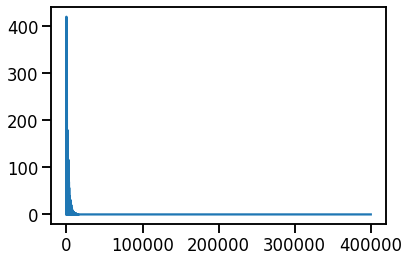

In [24]:
plt.plot(df_ef["E_reg"])

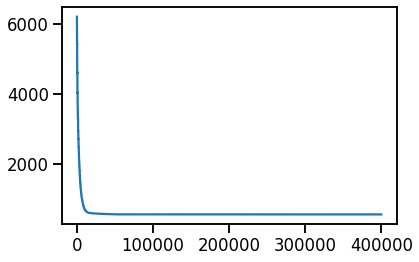

In [25]:
plt.plot(df_ef["E_tot"])